part4 - Preprocessing

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
#data loader
import torch

from utils.dataset import load_datasets
from utils.transforms import train_transform, test_transform

train_dataset, val_dataset, test_dataset = load_datasets(
    train_transform=train_transform,
    test_transform=test_transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [3]:
#Check a Batch
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


In [4]:
#View Tensor information
print("Image dtype :", images.dtype)
print("Min Value   :", images.min().item())
print("Max Value   :", images.max().item())

Image dtype : torch.float32
Min Value   : -2.1179039478302
Max Value   : 2.640000104904175


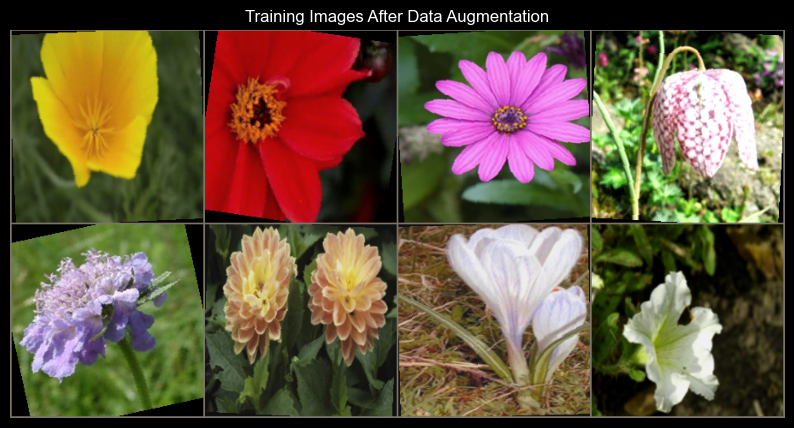

Labels:
- Californian Poppy
- Bishop of Llandaff
- Osteospermum
- Fritillary
- Pincushion Flower
- Pink-Yellow Dahlia
- Spring Crocus
- Petunia


In [5]:
#Visual data augmentation
import matplotlib.pyplot as plt
import torchvision

from utils.flower_names import FLOWER_NAMES
from utils.transforms import IMAGENET_MEAN, IMAGENET_STD

images, labels = next(iter(train_loader))

grid = torchvision.utils.make_grid(images[:8], nrow=4)

img = grid.numpy().transpose((1, 2, 0))


mean = IMAGENET_MEAN
std = IMAGENET_STD

img = img * std + mean
img = img.clip(0, 1)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Training Images After Data Augmentation")
plt.show()

print("Labels:")
for label in labels[:8]:
    print("-", FLOWER_NAMES[label.item()])

In [6]:
#Verify DataLoader
print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 32
Validation batches : 32
Test batches : 193
